<a href="https://colab.research.google.com/github/Proayush22/Abbott-District-Research/blob/main/Abbot_Districts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

#Classification/Regression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Data Loading
#Download google sheet as csv in excel (that worked for me), then upload it to your google drive to load the data
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/MasterFile for Abbot districts - Compiled Sheet.csv'

data = pd.read_csv(file_path)

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/MasterFile for Abbot districts - Compiled Sheet.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Drop ID columns
data = data.drop(columns = ['ID Geography'])
data.head()

,ID Group,Group,ID Subgroup,Subgroup,ID Occupation,Occupation,ID Year,Year,ID State,State,...,ACS Occupation yg RCA,Geography,Slug Geography,Median Earnings,Median Earnings Moe,Workforce Prev,Workforce Growth,Median Earnings Prev,Median Earnings Growth,Share
0,0,"Management, Business, Science, & Arts Occupations",0,"Management, Business, & Financial Occupations",0,Management Occupations,2022,2022,04000US34,New Jersey,...,0.404726,"Camden, NJ",camden-nj,141164,72038,1039.0,11.453321,141028.0,0.096435,4.460022
1,0,"Management, Business, Science, & Arts Occupations",0,"Management, Business, & Financial Occupations",1,Business & Financial Operations Occupations,2022,2022,04000US34,New Jersey,...,0.528671,"Camden, NJ",camden-nj,127346,29065,827.0,-4.353083,111164.0,14.556871,3.046526
2,0,"Management, Business, Science, & Arts Occupations",1,"Computer, Engineering, & Science Occupations",2,Computer & Mathematical Occupations,2022,2022,04000US34,New Jersey,...,0.241497,"Camden, NJ",camden-nj,83417,52435,218.0,1.376147,79333.0,5.147921,0.851179
3,0,"Management, Business, Science, & Arts Occupations",1,"Computer, Engineering, & Science Occupations",3,Architecture & Engineering Occupations,2022,2022,04000US34,New Jersey,...,0.215046,"Camden, NJ",camden-nj,55921,26974,134.0,-10.447761,52813.0,5.884915,0.462178
4,0,"Management, Business, Science, & Arts Occupations",2,"Education, Legal, Community Service, Arts, & M...",5,Community & Social Service Occupations,2022,2022,04000US34,New Jersey,...,1.360698,"Camden, NJ",camden-nj,96287,29905,686.0,-8.017493,108897.0,-11.579750,2.430288


In [ ]:
#Get all the diverse classes in 'Occupation'
occupations_list = data['Occupation'].unique()
print(occupations_list)

['Management Occupations' 'Business & Financial Operations Occupations'
 'Computer & Mathematical Occupations'
 'Architecture & Engineering Occupations'
 'Community & Social Service Occupations' 'Legal Occupations'
 'Education Instruction, & Library Occupations'
 'Arts, Design, Entertainment, Sports, & Media Occupations'
 'Health Diagnosing & Treating Practitioners & Other Technical Occupations'
 'Health Technologists & Technicians' 'Healthcare Support Occupations'
 'Food Preparation & Serving Related Occupations'
 'Building & Grounds Cleaning & Maintenance Occupations'
 'Personal Care & Service Occupations'
 'Fire Fighting & Prevention, & Other Protective Service Workers Including Supervisors'
 'Law Enforcement Workers Including Supervisors'
 'Sales & Related Occupations'
 'Office & Administrative Support Occupations'
 'Construction & Extraction Occupations'
 'Installation, Maintenance, & Repair Occupations'
 'Production Occupations' 'Transportation Occupations'
 'Life, Physical, & So

In [ ]:
data.describe()

,ID Group,ID Subgroup,ID Occupation,ID Year,Year,Workforce by Occupation and Gender,Workforce by Occupation and Gender Moe,ACS Occupation yg RCA,Median Earnings,Median Earnings Moe,Workforce Prev,Workforce Growth,Median Earnings Prev,Median Earnings Growth,Share
count,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1384.000000,1243.000000,1243.000000,1236.000000,1236.000000,1384.000000
mean,1.124277,3.839595,11.546243,2017.465318,2017.465318,2352.392341,312.930441,0.985917,79205.463873,37272.783960,2328.074819,4.173110,77513.651294,7.946030,4.014066
std,1.331694,2.451908,6.923455,2.876129,2.876129,3256.482867,225.842391,0.597842,49093.323386,50956.064713,3209.322904,21.682030,47748.939549,71.289676,3.372358
min,0.000000,0.000000,0.000000,2013.000000,2013.000000,26.000000,31.400637,0.076032,4271.000000,799.000000,23.000000,-66.257669,4271.000000,-90.241975,0.046041
25%,0.000000,2.000000,6.000000,2015.000000,2015.000000,366.000000,140.681377,0.553303,43189.250000,9185.750000,358.000000,-5.893925,42192.000000,-3.091598,1.318109
50%,1.000000,4.000000,12.000000,2017.000000,2017.000000,1010.000000,252.758698,0.851369,63107.000000,19926.000000,993.000000,1.853394,61138.500000,2.365324,2.885350
75%,2.000000,6.000000,17.000000,2020.000000,2020.000000,2732.750000,425.522029,1.270619,106943.000000,44536.000000,2734.500000,10.527295,105481.750000,9.532979,6.045397
max,4.000000,8.000000,23.000000,2022.000000,2022.000000,18924.000000,1286.307117,3.893879,316488.000000,390387.000000,18602.000000,257.500000,316488.000000,2065.073886,16.227150


In [ ]:
geography_list = data["Geography"].unique()
print(geography_list)
city_to_index = {city: index for index, city in enumerate(geography_list)}
print(city_to_index)
data["ID Geography"] = data["Geography"].map(city_to_index)
index_to_city = {index: city for index, city in enumerate(geography_list)}
print(index_to_city)
data.head()

['Camden, NJ' 'Trenton, NJ' 'New Brunswick, NJ' 'Asbury Park, NJ'
 'Jersey City, NJ' 'Newark, NJ']
{'Camden, NJ': 0, 'Trenton, NJ': 1, 'New Brunswick, NJ': 2, 'Asbury Park, NJ': 3, 'Jersey City, NJ': 4, 'Newark, NJ': 5}
{0: 'Camden, NJ', 1: 'Trenton, NJ', 2: 'New Brunswick, NJ', 3: 'Asbury Park, NJ', 4: 'Jersey City, NJ', 5: 'Newark, NJ'}


,ID Group,Group,ID Subgroup,Subgroup,ID Occupation,Occupation,ID Year,Year,ID State,State,...,Geography,Slug Geography,Median Earnings,Median Earnings Moe,Workforce Prev,Workforce Growth,Median Earnings Prev,Median Earnings Growth,Share,ID Geography
0,0,"Management, Business, Science, & Arts Occupations",0,"Management, Business, & Financial Occupations",0,Management Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,141164,72038,1039.0,11.453321,141028.0,0.096435,4.460022,0
1,0,"Management, Business, Science, & Arts Occupations",0,"Management, Business, & Financial Occupations",1,Business & Financial Operations Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,127346,29065,827.0,-4.353083,111164.0,14.556871,3.046526,0
2,0,"Management, Business, Science, & Arts Occupations",1,"Computer, Engineering, & Science Occupations",2,Computer & Mathematical Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,83417,52435,218.0,1.376147,79333.0,5.147921,0.851179,0
3,0,"Management, Business, Science, & Arts Occupations",1,"Computer, Engineering, & Science Occupations",3,Architecture & Engineering Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,55921,26974,134.0,-10.447761,52813.0,5.884915,0.462178,0
4,0,"Management, Business, Science, & Arts Occupations",2,"Education, Legal, Community Service, Arts, & M...",5,Community & Social Service Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,96287,29905,686.0,-8.017493,108897.0,-11.579750,2.430288,0


In [ ]:
data["Year"] = pd.to_datetime(data["Year"].astype(str) + "+01+01", format = '%Y+%m+%d')
data.head()

,ID Group,Group,ID Subgroup,Subgroup,ID Occupation,Occupation,ID Year,Year,ID State,State,...,Geography,Slug Geography,Median Earnings,Median Earnings Moe,Workforce Prev,Workforce Growth,Median Earnings Prev,Median Earnings Growth,Share,ID Geography
0,0,"Management, Business, Science, & Arts Occupations",0,"Management, Business, & Financial Occupations",0,Management Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,141164,72038,1039.0,11.453321,141028.0,0.096435,4.460022,0
1,0,"Management, Business, Science, & Arts Occupations",0,"Management, Business, & Financial Occupations",1,Business & Financial Operations Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,127346,29065,827.0,-4.353083,111164.0,14.556871,3.046526,0
2,0,"Management, Business, Science, & Arts Occupations",1,"Computer, Engineering, & Science Occupations",2,Computer & Mathematical Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,83417,52435,218.0,1.376147,79333.0,5.147921,0.851179,0
3,0,"Management, Business, Science, & Arts Occupations",1,"Computer, Engineering, & Science Occupations",3,Architecture & Engineering Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,55921,26974,134.0,-10.447761,52813.0,5.884915,0.462178,0
4,0,"Management, Business, Science, & Arts Occupations",2,"Education, Legal, Community Service, Arts, & M...",5,Community & Social Service Occupations,2022,2022-01-01,04000US34,New Jersey,...,"Camden, NJ",camden-nj,96287,29905,686.0,-8.017493,108897.0,-11.579750,2.430288,0


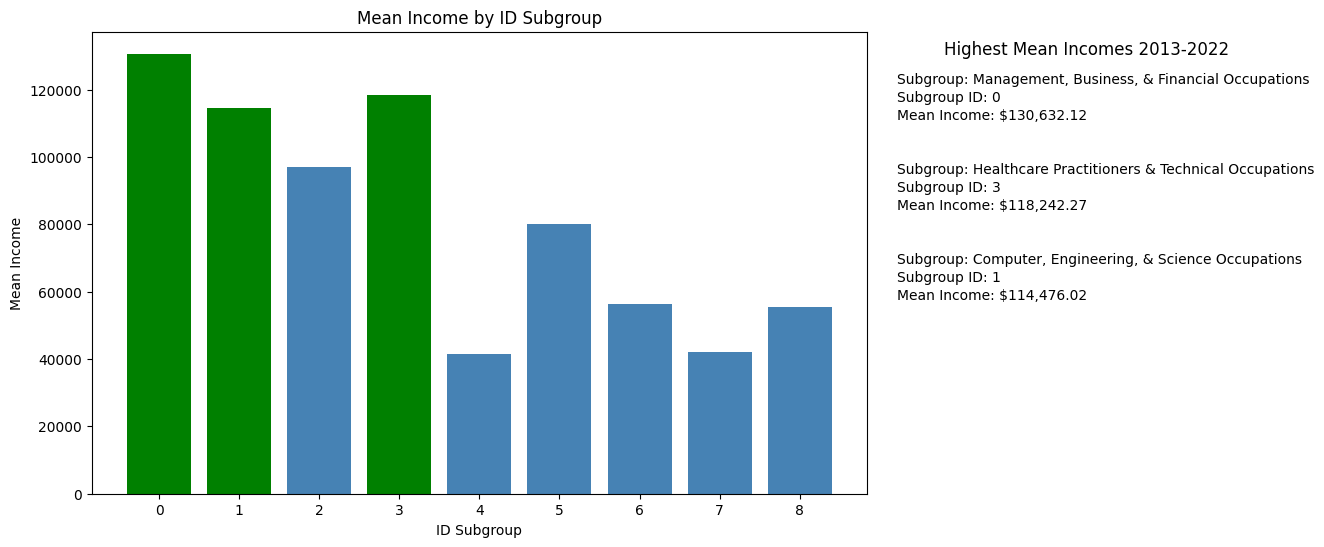

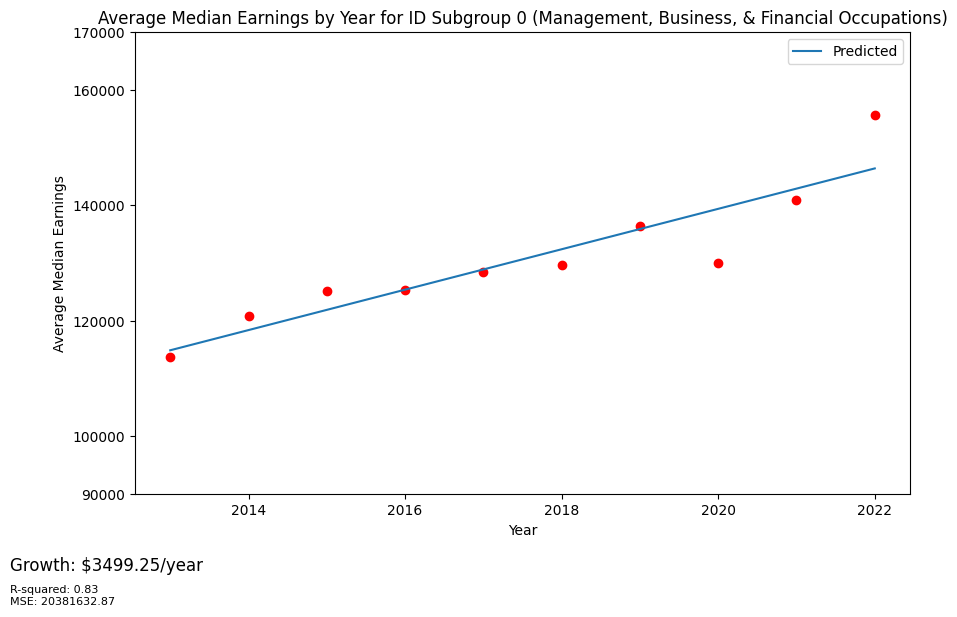

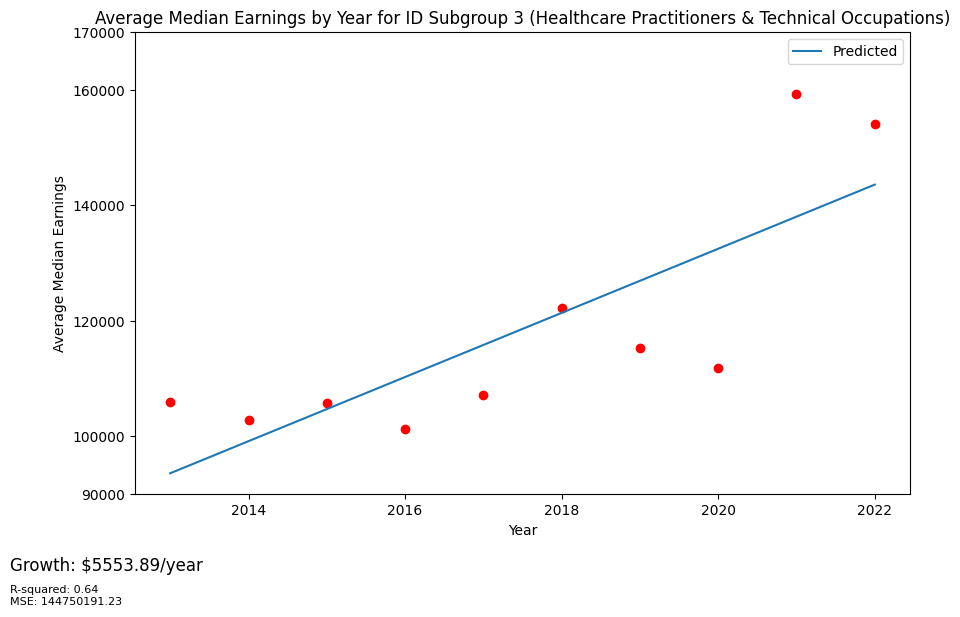

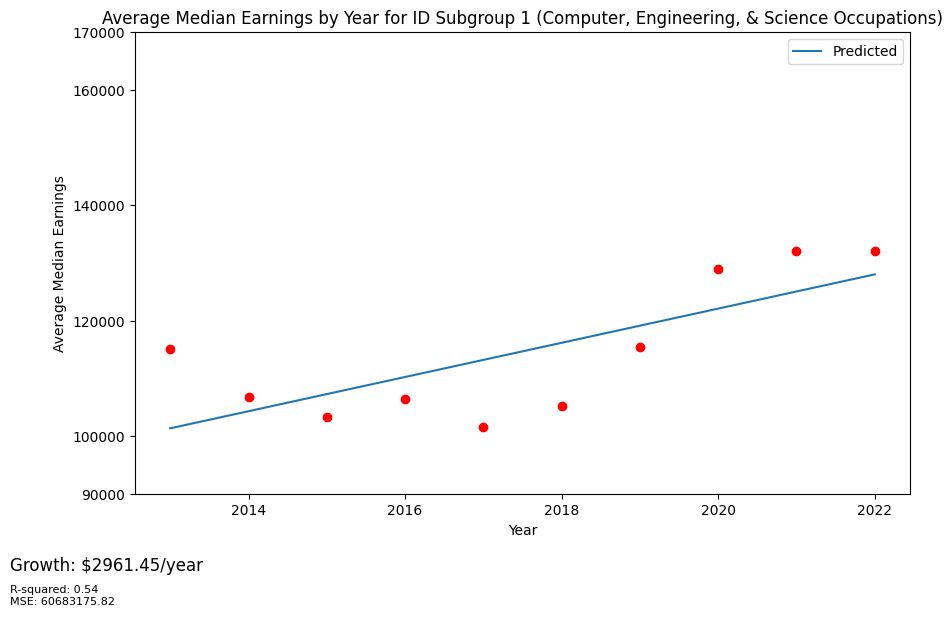

In [ ]:
id_to_subgroup = {}

X = data['ID Subgroup']
Y = data['Median Earnings']
subgroups = data["Subgroup"]
for i in X:
  id_to_subgroup[i] = subgroups[X == i].unique()[0]

mean_earnings = data.groupby('ID Subgroup')['Median Earnings'].mean().reset_index()
mean_earnings = pd.DataFrame(mean_earnings)
X = mean_earnings['ID Subgroup']
Y = mean_earnings['Median Earnings']


highest = mean_earnings.sort_values(by = 'Median Earnings', ascending = False).head(3)
colors = ["steelblue"] * len(X)
for i in highest.index:
  colors[i] = "green"

plt.figure(figsize=(10, 6))
plt.bar(X, Y, color=colors)
plt.xticks(X)
plt.xlabel('ID Subgroup')
plt.ylabel('Mean Income')
plt.title('Mean Income by ID Subgroup')
plt.figtext(1.12, 0.85, 'Highest Mean Incomes 2013-2022', fontsize=12, ha='center', va='center')
text_y = 0.8
for subgroup_id in highest['ID Subgroup']:
  plt.figtext(0.93, text_y, f"Subgroup: {id_to_subgroup[subgroup_id]}", fontsize=10, ha='left', va='center')
  plt.figtext(0.93, text_y - 0.03, f"Subgroup ID: {subgroup_id}", fontsize=10, ha='left', va='center')

  plt.figtext(0.93, text_y - 0.06, f"Mean Income: ${mean_earnings[mean_earnings['ID Subgroup'] == subgroup_id]['Median Earnings'].values[0]:,.2f}", fontsize=10, ha='left', va='center')
  text_y -= 0.15
plt.show()

for i in highest.index:
  lin_reg_data = data[data['ID Subgroup'] == i].groupby('ID Year')['Median Earnings'].mean().reset_index()
  X = lin_reg_data['ID Year']
  Y = lin_reg_data['Median Earnings']
  model = LinearRegression()
  model.fit(X.values.reshape(-1, 1), Y)
  y_pred = model.predict(X.values.reshape(-1, 1))
  mse = mean_squared_error(Y, y_pred)
  r2 = r2_score(Y, y_pred)
  plt.figure(figsize=(10, 6))
  plt.scatter(X, Y, color="red")
  plt.plot(X, y_pred, label='Predicted')
  plt.yticks([90000, 100000, 120000, 140000, 160000, 170000])
  plt.xlabel('Year')
  plt.ylabel('Average Median Earnings')
  plt.title(f'Average Median Earnings by Year for ID Subgroup {i} ({id_to_subgroup[i]})')
  plt.figtext(0, -0.01, f'Growth: ${model.coef_[0]:.2f}/year', fontsize=12, ha='left', va='center')
  plt.figtext(0, -0.05, f'R-squared: {r2:.2f}', fontsize=8, ha='left', va='center')
  plt.figtext(0, -0.07, f'MSE: {mse:.2f}', fontsize=8, ha='left', va='center')
  plt.legend()
  plt.show()

In [ ]:
#Data Scaling
data_features = data[["ID Subgroup", "ID Occupation", "ID Geography", "Workforce by Occupation and Gender", "Workforce Growth", "Median Earnings Growth"]]
X = data_features.fillna(data_features.mean())
Y = data['Median Earnings']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 1468892040.44
R-squared: 0.41


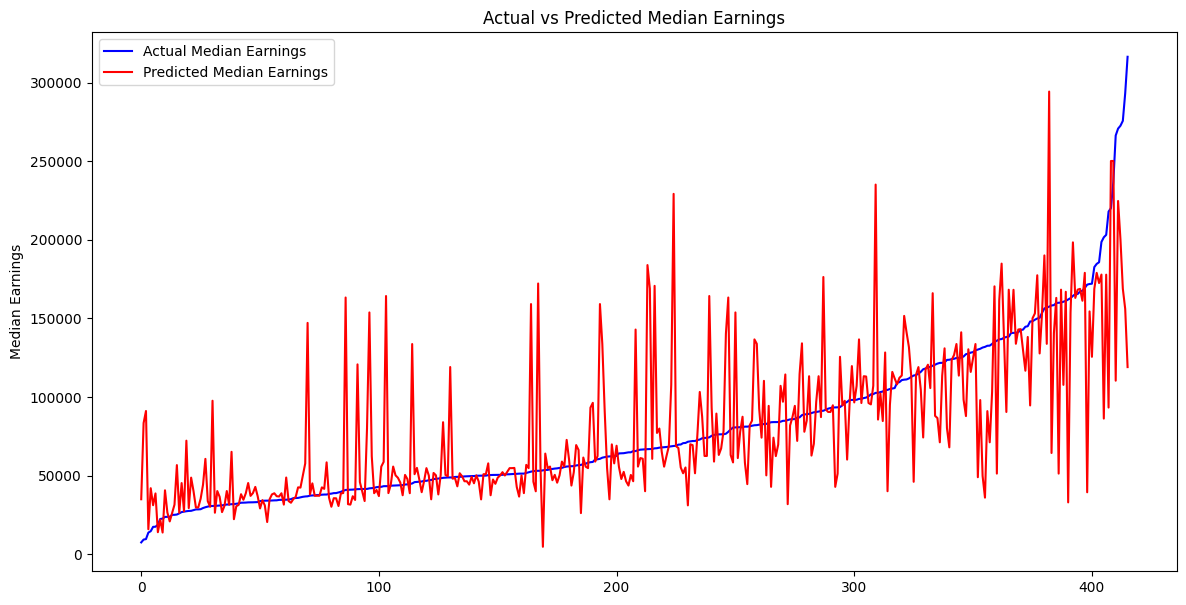

In [ ]:
sorted_indices = y_test.argsort()
y_test_sorted = y_test.values[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Plot the actual and predicted values
plt.figure(figsize=(14, 7))
plt.plot(range(len(y_test)), y_test_sorted, color='blue', label='Actual Median Earnings')
plt.plot(range(len(y_test)), y_pred_sorted, color='red', label='Predicted Median Earnings')
plt.ylabel('Median Earnings')
plt.title('Actual vs Predicted Median Earnings')
plt.legend()
plt.show()

Mean Squared Error: 72181541.9069472
R-squared: 0.97


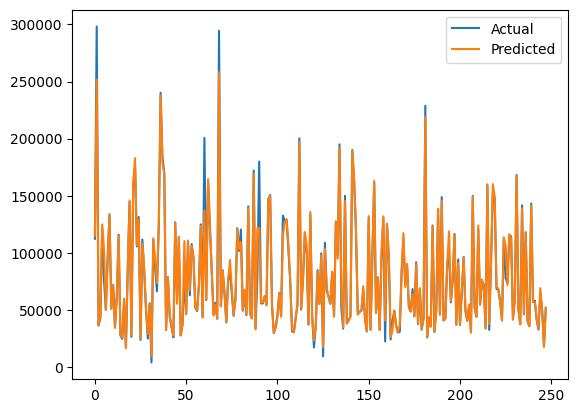

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_data = data[["ID Geography", "ID Year", "ID Subgroup", "Workforce Prev", "Workforce Growth", "Median Earnings Prev", "Median Earnings Growth", "Median Earnings"]]
rf_data.replace('', np.nan, inplace=True)
rf_data.dropna(inplace=True)
Y = rf_data["Median Earnings"]
X = rf_data.drop(columns = ["Median Earnings"])


X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2:.2f}')

X = np.arange(len(y_test))
plt.plot(X, y_test, label='Actual')
plt.plot(X, y_pred, label='Predicted')
plt.legend()
plt.show()


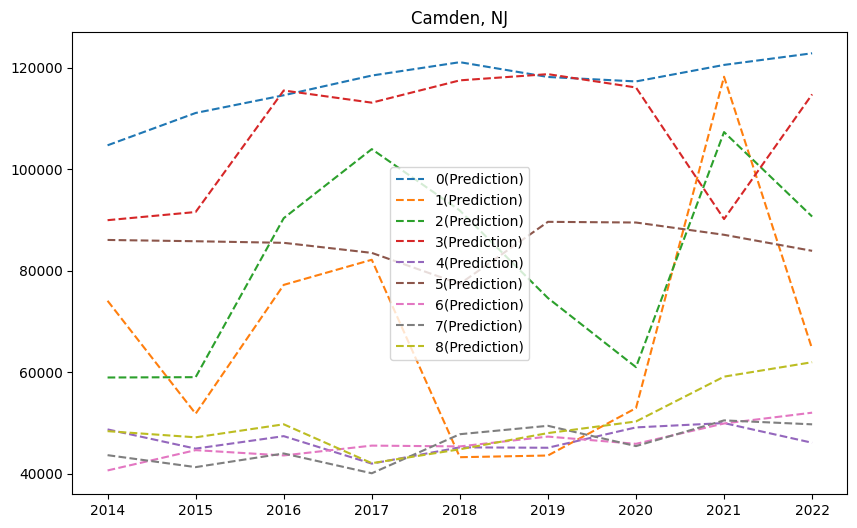

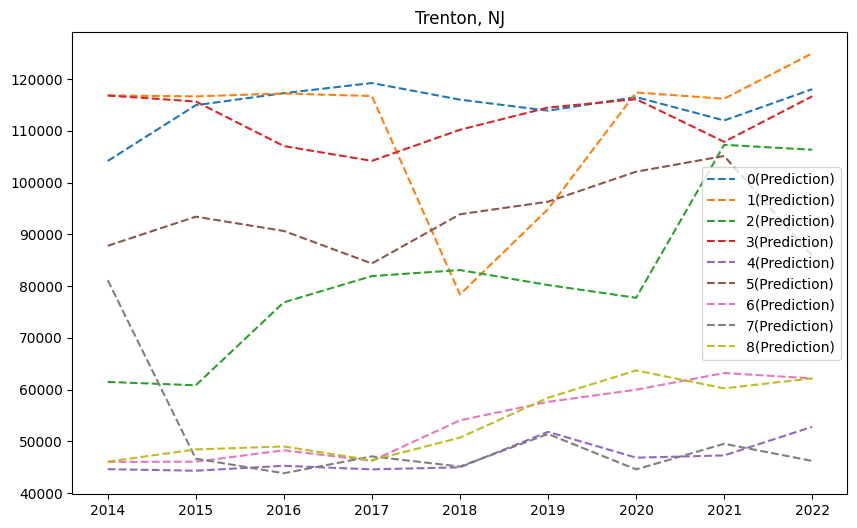

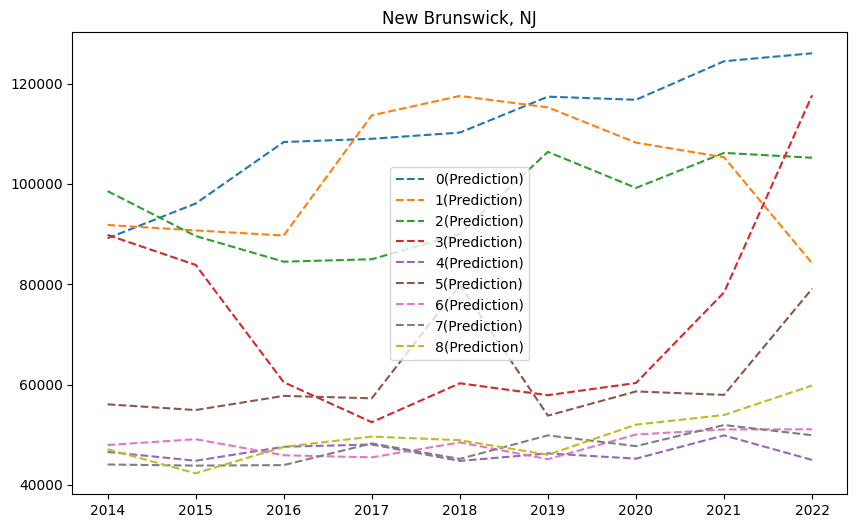

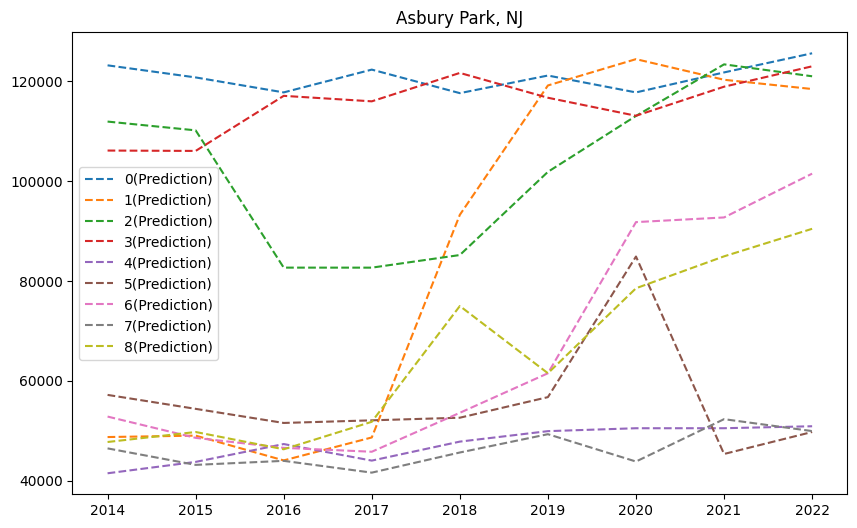

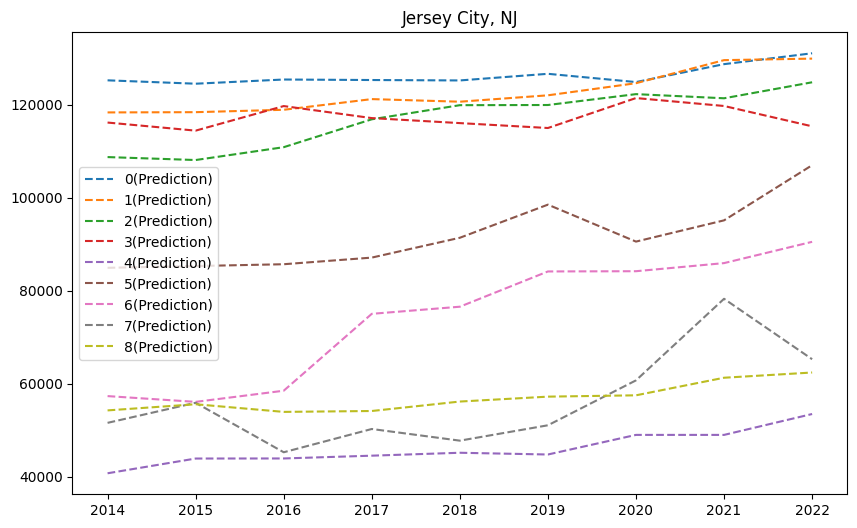

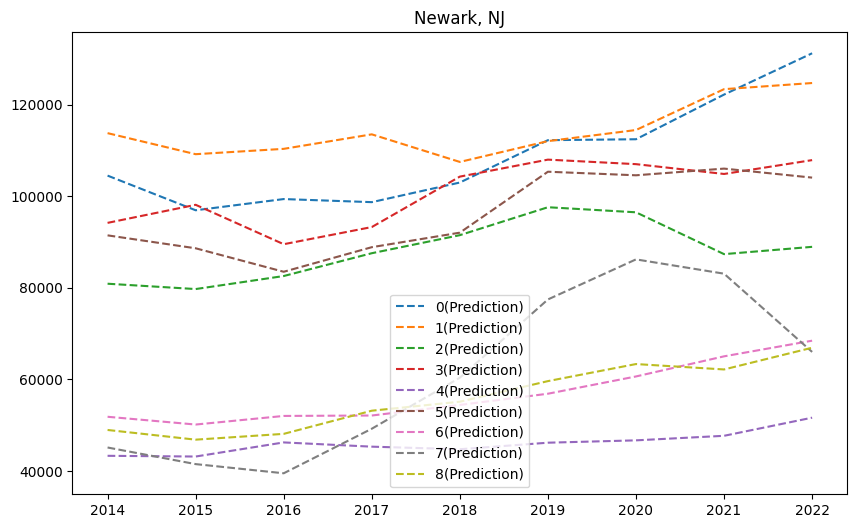

In [ ]:
Frf_data = data[["ID Geography", "ID Year", "ID Subgroup", "Workforce Prev", "Workforce Growth", "Median Earnings Prev", "Median Earnings Growth", "Median Earnings"]]
rf_data.replace('', np.nan, inplace=True)
rf_data.dropna(inplace=True)

rf_data = rf_data.groupby(['ID Geography', 'ID Year', 'ID Subgroup']).mean().reset_index()
for i in range(6):
  geography_data = rf_data[rf_data['ID Geography'] == i]
  plt.figure(figsize=(10,6))
  plt.title(f'{index_to_city[i]}')
  colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']
  for subgroup in geography_data['ID Subgroup'].unique():
    subgroup_data = geography_data[geography_data['ID Subgroup'] == subgroup]
    X = subgroup_data.drop(columns = ['Median Earnings'])
    Y = subgroup_data['Median Earnings']
    y_pred = model.predict(X)
    X = subgroup_data['ID Year']
    plt.plot(X, y_pred, label=f'{subgroup}(Prediction)', linestyle='--', color = colors[subgroup])
    # plt.plot(X, Y, label=f'{subgroup}(Actual)', color = colors[subgroup])
  plt.legend()
  plt.show()


